#**PHRONESIS (GROUP 10)**
INDEX NUMBERS

22425980

22425084

22428645

22425055

22425717

22425147

22425053

22424742

# **STROKE PREDICTION**

This notebook focuses on the preprocessing of a stroke prediction dataset. The steps include handling missing values, feature engineering and employing sampling techniques (oversampling and undersampling) to balance the dataset and prepare it for model training.

In [ ]:
import pandas as pd
import numpy as np
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from imblearn.combine import SMOTETomek
from sklearn.utils import resample
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv("/content/dataset.csv")
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,30669,Male,3.0,0,0,No,children,Rural,95.12,18.0,NaN,0
1,30468,Male,58.0,1,0,Yes,Private,Urban,87.96,39.2,never smoked,0
2,16523,Female,8.0,0,0,No,Private,Urban,110.89,17.6,NaN,0
3,56543,Female,70.0,0,0,Yes,Private,Rural,69.04,35.9,formerly smoked,0
4,46136,Male,14.0,0,0,No,Never_worked,Rural,161.28,19.1,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...
43395,56196,Female,10.0,0,0,No,children,Urban,58.64,20.4,never smoked,0
43396,5450,Female,56.0,0,0,Yes,Govt_job,Urban,213.61,55.4,formerly smoked,0
43397,28375,Female,82.0,1,0,Yes,Private,Urban,91.94,28.9,formerly smoked,0
43398,27973,Male,40.0,0,0,Yes,Private,Urban,99.16,33.2,never smoked,0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Check_for_duplicates
df.duplicated().sum()

np.int64(0)

In [ ]:
#Check_for_missing_values
df.isnull().sum()


,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,1462


In [ ]:
#Total_missing_values
df.isnull().sum().sum()

np.int64(14754)

In [ ]:
# 1. Impute BMI using median
median_bmi = df['bmi'].median()
df['bmi'] = df['bmi'].fillna(median_bmi)

# 2. Impute smoking_status using "Unknown"
df['smoking_status'] = df['smoking_status'].fillna("Unknown")

# Check again for missing values
clean_missing = df.isna().sum()
clean_missing

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0


In [ ]:
df['heart_disease'].value_counts()

,count
heart_disease,
0,41338
1,2062


In [ ]:
df['hypertension'].value_counts()

,count
hypertension,
0,39339
1,4061


In [ ]:
df['stroke'].value_counts()

,count
stroke,
0,42617
1,783


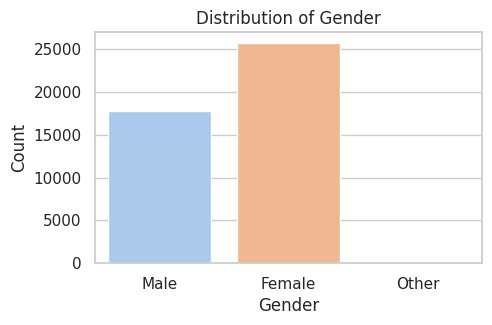

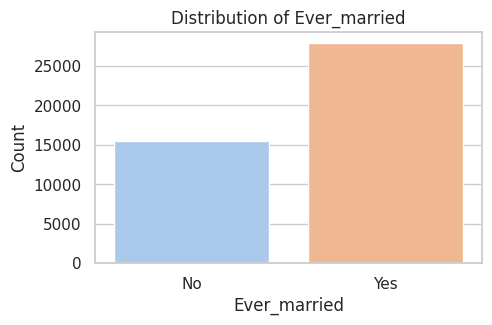

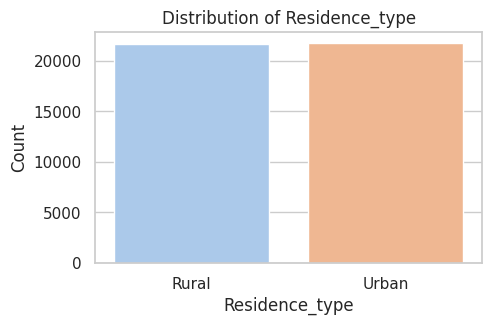

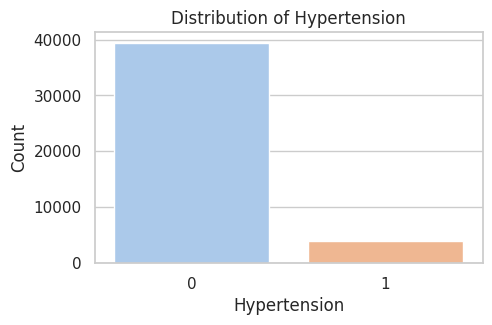

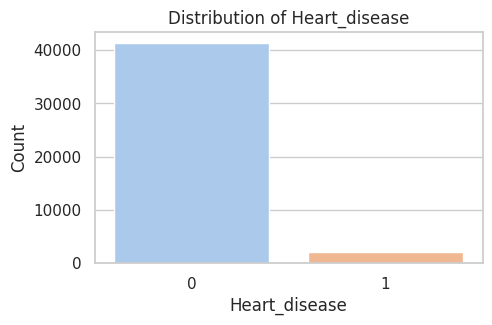

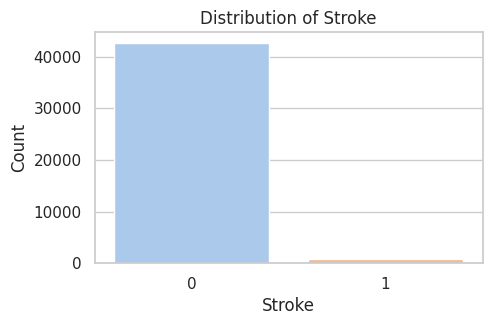

In [ ]:
# List of binary features to plot
binary_cols = ['gender', 'ever_married', 'Residence_type', 'hypertension', 'heart_disease', 'stroke']
sns.set(style="whitegrid")

for col in binary_cols:
    plt.figure(figsize=(5, 3))
    sns.countplot(x=col, hue=col, data=df, palette="pastel", legend=False)
    plt.title(f"Distribution of {col.capitalize()}")
    plt.xlabel(col.capitalize())
    plt.ylabel("Count")
    plt.show()

In [ ]:
# Select only numerical columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("Numeric Columns:", list(numeric_cols))

Numeric Columns: ['id', 'age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']


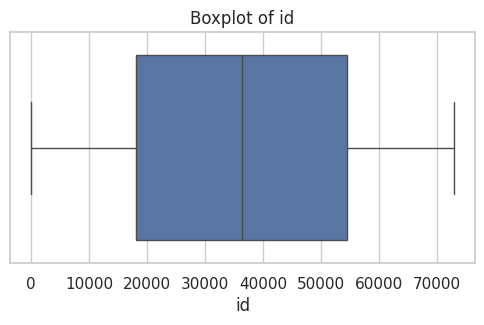

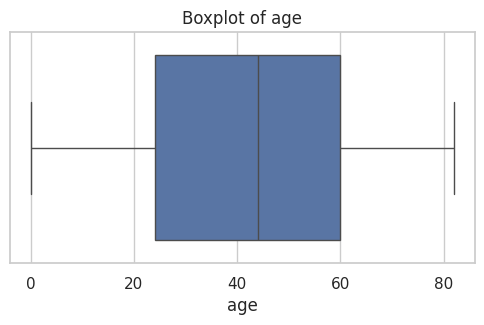

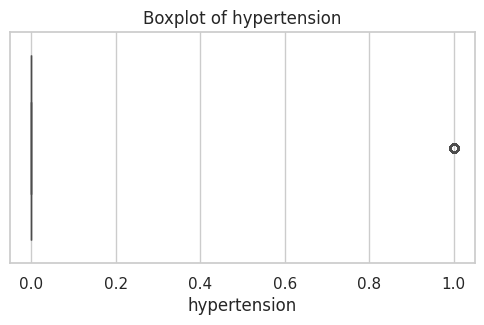

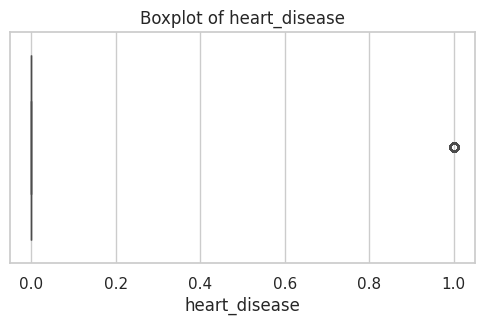

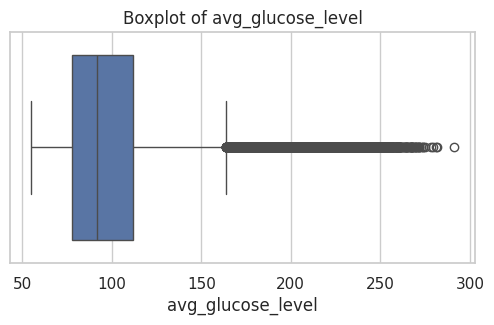

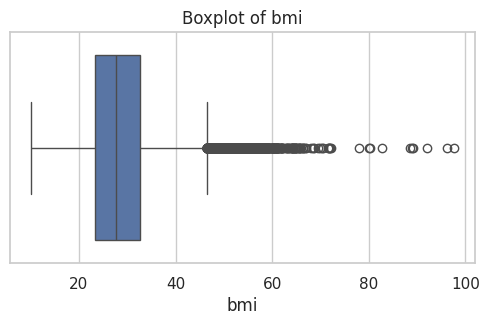

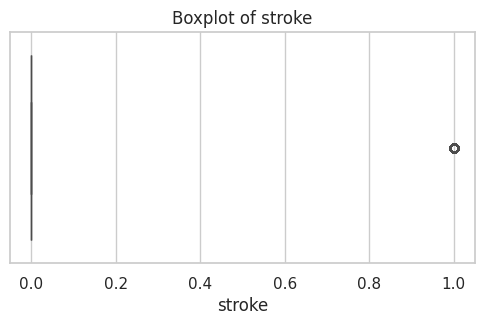

In [ ]:
## Checking for outliers
for col in numeric_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [ ]:
def detect_outliers_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
    return outliers.shape[0]

print("\n--- Outliers Detected Using IQR Method ---")
for col in numeric_cols:
    n_outliers = detect_outliers_iqr(df, col)
    print(f"{col}: {n_outliers} outliers")


--- Outliers Detected Using IQR Method ---
id: 0 outliers
age: 0 outliers
hypertension: 4061 outliers
heart_disease: 2062 outliers
avg_glucose_level: 4978 outliers
bmi: 1084 outliers
stroke: 783 outliers


In [ ]:
outlier_summary = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outlier_pct = ((df[col] < lower) | (df[col] > upper)).mean() * 100
    outlier_summary[col] = round(outlier_pct, 2)

outlier_summary = pd.Series(outlier_summary, name="Outlier Percentage (%)")
print("\n--- Outlier Percentages per Feature ---")
print(outlier_summary)


--- Outlier Percentages per Feature ---
id                    0.00
age                   0.00
hypertension          9.36
heart_disease         4.75
avg_glucose_level    11.47
bmi                   2.50
stroke                1.80
Name: Outlier Percentage (%), dtype: float64


# Justification for Random Oversampling Technique
The dataset used in this project contains significant **class imbalance** in three key binary target variables:
- `stroke` (~1.8% positive cases)
- `heart_disease` (~5% positive cases)
- `hypertension` (~9% positive cases)

Class imbalance can severely degrade model performance, as most classification algorithms tend to **favor the majority class**, leading to poor sensitivity and recall for minority cases (which are often the most clinically important).

---

##Why Random Oversampling?
### 1. **Preserves Original Information**
Random oversampling duplicates existing minority-class samples until both classes are balanced.  
Unlike undersampling, it does **not discard any majority samples**, preserving all available patient data — crucial for medical datasets where every record carries potential clinical value.

### 2. **Maintains Feature Relationships**
Since the synthetic data points are direct copies of real observations, oversampling **preserves true statistical relationships** between predictors and outcomes (e.g., between `hypertension`, `heart_disease`, and `stroke`).

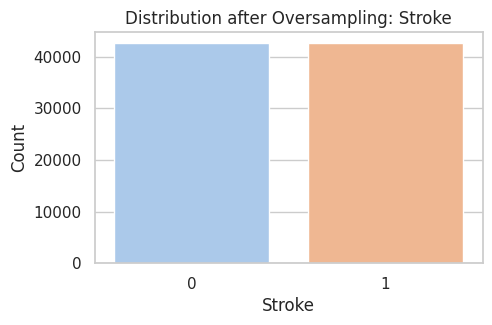

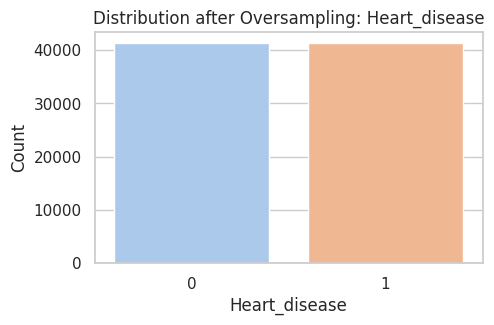

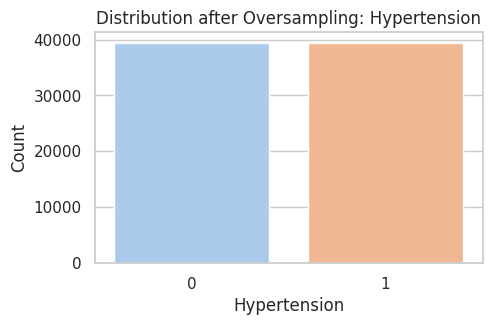

Stroke class balance after oversampling:
stroke
1    50.0
0    50.0
Name: proportion, dtype: float64

Heart_disease class balance after oversampling:
heart_disease
1    50.0
0    50.0
Name: proportion, dtype: float64

Hypertension class balance after oversampling:
hypertension
0    50.0
1    50.0
Name: proportion, dtype: float64



In [ ]:
# Encode categorical variables (convert to numeric)
df_encoded = pd.get_dummies(df, drop_first=True)

# Apply Random Oversampling
balanced_dfs = {}
for col in ['stroke', 'heart_disease', 'hypertension']:
    # Separate majority and minority classes
    df_majority = df_encoded[df_encoded[col] == 0]
    df_minority = df_encoded[df_encoded[col] == 1]

    # Oversample the minority class
    df_minority_oversampled = resample(
        df_minority,
        replace=True,               # Sample with replacement
        n_samples=len(df_majority), # Match majority size
        random_state=42             # Reproducibility
    )

    # Combine majority and oversampled minority
    df_balanced = pd.concat([df_majority, df_minority_oversampled])

    # Shuffle the dataset
    df_balanced = df_balanced.sample(frac=1,
                                     random_state=42).reset_index(drop=True)

    # Store in dictionary
    balanced_dfs[col] = df_balanced

# Plot Bar Graphs for Each Balanced Variable
sns.set(style="whitegrid")

for col, balanced_df in balanced_dfs.items():
    plt.figure(figsize=(5, 3))
    sns.countplot(x=col, hue=col, data=balanced_df, palette="pastel")
    plt.title(f"Distribution after Oversampling: {col.capitalize()}")
    plt.xlabel(col.capitalize())
    plt.ylabel("Count")
    plt.legend([], [], frameon=False)
    plt.show()

#  Verify Class Balance Numerically
for col, balanced_df in balanced_dfs.items():
    balance = balanced_df[col].value_counts(normalize=True) * 100
    print(f"{col.capitalize()} class balance after oversampling:\n{balance}\n")


###**FEATURE ENGINEERING**
Performing feature engineering by selecting the 'stroke' balanced dataset from `balanced_dfs`, identifying numerical features (excluding 'id' and 'stroke') for scaling, applying a suitable scaling technique (`StandardScaler`) to these features, and finally splitting the preprocessed data into training and testing sets for model building.

In [ ]:
df_stroke_balanced = balanced_dfs['stroke']
print("Shape of df_stroke_balanced:", df_stroke_balanced.shape)
df_stroke_balanced.head()

Shape of df_stroke_balanced: (85234, 18)


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,gender_Other,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,19985,68.0,1,0,84.73,28.3,1,True,False,True,False,True,False,False,True,False,False,True
1,6937,46.0,0,0,186.68,27.7,1,False,False,True,False,False,True,False,False,False,True,False
2,38047,65.0,0,0,100.98,28.2,1,False,False,True,False,True,False,False,False,True,False,False
3,37295,28.0,0,0,78.27,25.2,0,True,False,True,False,True,False,False,False,False,False,True
4,23790,16.0,0,0,78.06,26.3,0,True,False,False,False,True,False,False,True,False,True,False



Identifying the numerical features in the `df_stroke_balanced` DataFrame that need to be scaled, excluding the 'id' column and the target 'stroke' column.



In [ ]:
numerical_features = df_stroke_balanced.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_features_to_scale = [col for col in numerical_features if col not in ['id', 'stroke']]
print("Numerical features selected for scaling:", numerical_features_to_scale)

Numerical features selected for scaling: ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']



Applied StandardScaler to the identified numerical features to normalize their range, which is a common preprocessing step for many machine learning algorithms.



In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling to the selected numerical features
df_stroke_balanced[numerical_features_to_scale] = scaler.fit_transform(df_stroke_balanced[numerical_features_to_scale])

print("Numerical features after scaling:")
print(df_stroke_balanced[numerical_features_to_scale].head())

Numerical features after scaling:
        age  hypertension  heart_disease  avg_glucose_level       bmi
0  0.582790      2.176367      -0.395818          -0.596086 -0.106374
1 -0.400370     -0.459481      -0.395818           1.320048 -0.194443
2  0.448722     -0.459481      -0.395818          -0.290670 -0.121052
3 -1.204773     -0.459481      -0.395818          -0.717500 -0.561400
4 -1.741042     -0.459481      -0.395818          -0.721447 -0.399939



Split the preprocessed data into training and testing sets, separating features (X) from the target variable (y), to prepare for model training and evaluation.



In [ ]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df_stroke_balanced.drop(columns=['id', 'stroke'])
y = df_stroke_balanced['stroke']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)
print("\nClass distribution in y_train:\n", y_train.value_counts(normalize=True))
print("\nClass distribution in y_test:\n", y_test.value_counts(normalize=True))

Shape of X_train: (68187, 16)
Shape of X_test: (17047, 16)
Shape of y_train: (68187,)
Shape of y_test: (17047,)

Class distribution in y_train:
 stroke
1    0.500007
0    0.499993
Name: proportion, dtype: float64

Class distribution in y_test:
 stroke
0    0.500029
1    0.499971
Name: proportion, dtype: float64


## Summary:


*   The `df_stroke_balanced` dataset, with a shape of (85234, 18), was successfully selected for feature engineering.
*   Numerical features identified for scaling were 'age', 'hypertension', 'heart\_disease', 'avg\_glucose\_level', and 'bmi', explicitly excluding 'id' and 'stroke'.
*   `StandardScaler` was applied to these numerical features, transforming values to have a mean of 0 and a standard deviation of 1.
*   The data was split into training and testing sets with an 80/20 ratio using stratification based on the 'stroke' target variable.
    *   `X_train` has a shape of (68187, 16), `X_test` (17047, 16), `y_train` (68187,), and `y_test` (17047,).
    *   Both `y_train` and `y_test` maintained an approximate 50/50 class distribution for the 'stroke' variable, confirming successful stratification.



✅ Data split completed:
X_train: (68187, 17)
X_test: (17047, 17)
y_train: (68187,)
y_test: (17047,)

Class distribution in y_train:
 stroke
1    0.500007
0    0.499993
Name: proportion, dtype: float64

Class distribution in y_test:
 stroke
0    0.500029
1    0.499971
Name: proportion, dtype: float64


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [09:57:32] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



📊 Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.87      0.92      8524
           1       0.88      0.99      0.93      8523

    accuracy                           0.93     17047
   macro avg       0.94      0.93      0.93     17047
weighted avg       0.94      0.93      0.93     17047

✅ ROC-AUC Score: 0.9758787646841601


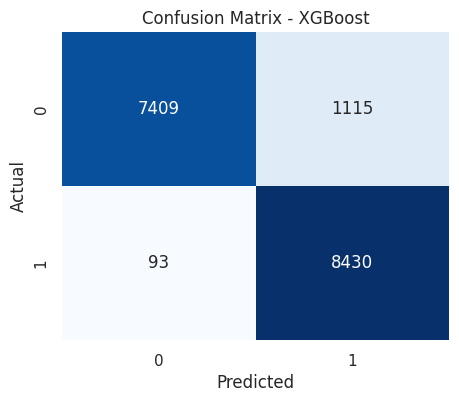

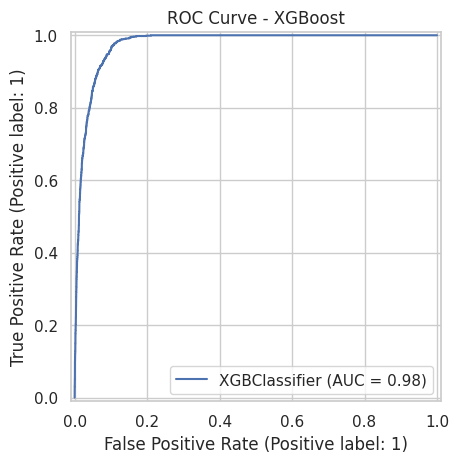

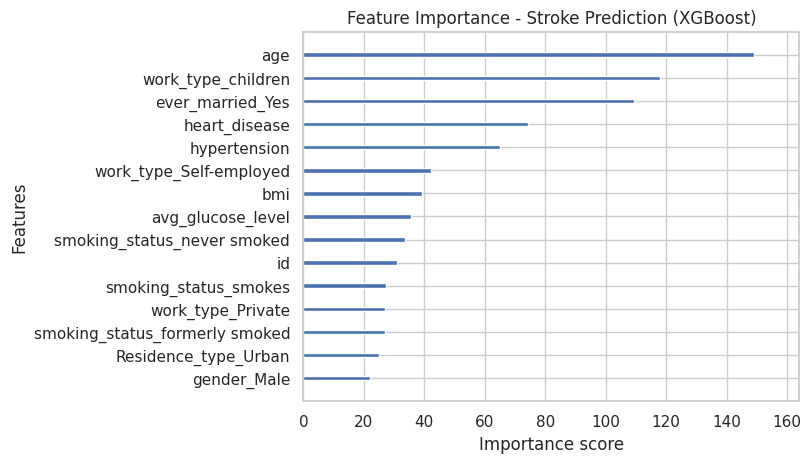

In [ ]:
# =========================================
# Import Required Libraries
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
import seaborn as sns
import matplotlib.pyplot as plt

# =========================================
#  Load and Prepare Dataset
# =========================================
# Use your balanced stroke dataset
# Make sure df_stroke_balanced exists or load it from file
# Example:
# df_stroke_balanced = pd.read_csv("balanced_stroke_dataset.csv")

# Separate features (X) and target (y)
X = df_stroke_balanced.drop(columns=['stroke'])
y = df_stroke_balanced['stroke']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("✅ Data split completed:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)
print("\nClass distribution in y_train:\n", y_train.value_counts(normalize=True))
print("\nClass distribution in y_test:\n", y_test.value_counts(normalize=True))

# =========================================
# 3️⃣ Train the XGBoost Model
# =========================================
# Compute class imbalance ratio (for weighting)
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# Initialize model
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    use_label_encoder=False
)

# Fit model
xgb_model.fit(X_train, y_train)

# =========================================
# 4️⃣ Evaluate Model
# =========================================
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred))
print("✅ ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve
RocCurveDisplay.from_estimator(xgb_model, X_test, y_test)
plt.title("ROC Curve - XGBoost")
plt.show()

# =========================================
# 5️⃣ Feature Importance Plot
# =========================================
xgb.plot_importance(xgb_model, importance_type='gain', show_values=False)
plt.title("Feature Importance - Stroke Prediction (XGBoost)")
plt.show()


Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.75      0.77      8477
           1       0.76      0.81      0.78      8570

    accuracy                           0.78     17047
   macro avg       0.78      0.78      0.78     17047
weighted avg       0.78      0.78      0.78     17047



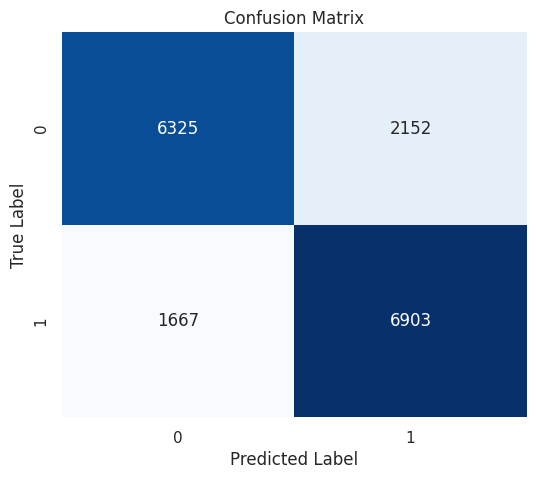

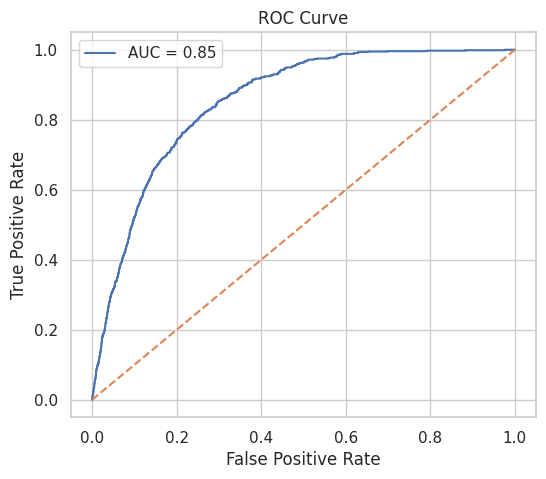

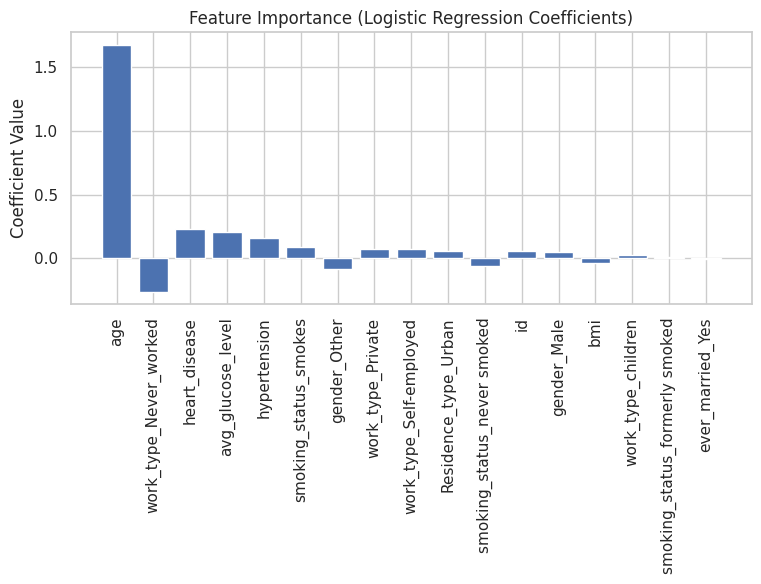

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Initialize and Train Logistic Regression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# 4. Predictions and Evaluation
y_pred = log_reg.predict(X_test_scaled)
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1] # Define y_prob for ROC curve

print("Classification Report:\n", classification_report(y_test, y_pred))

# 5. Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# 6. ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

# 7. Feature importance
feature_names = X.columns.tolist() # Get feature names from X DataFrame
coefficients = log_reg.coef_[0]

plt.figure(figsize=(8, 6))
sorted_idx = np.argsort(np.abs(coefficients))[::-1]
plt.bar(range(len(coefficients)), coefficients[sorted_idx], tick_label=np.array(feature_names)[sorted_idx])
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.xticks(rotation=90)
plt.ylabel("Coefficient Value")
plt.tight_layout()
plt.show()



📊 Classification Report - RandomForestClassifier:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8477
           1       1.00      1.00      1.00      8570

    accuracy                           1.00     17047
   macro avg       1.00      1.00      1.00     17047
weighted avg       1.00      1.00      1.00     17047

✅ ROC-AUC Score - RandomForestClassifier: 1.0000000000000002


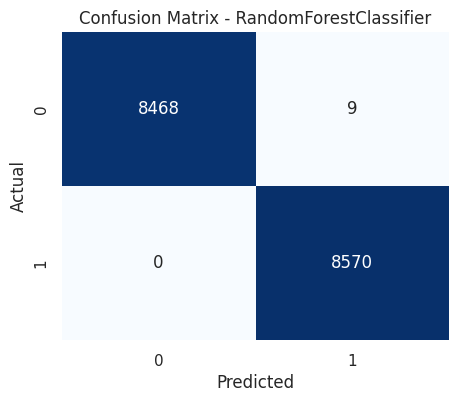

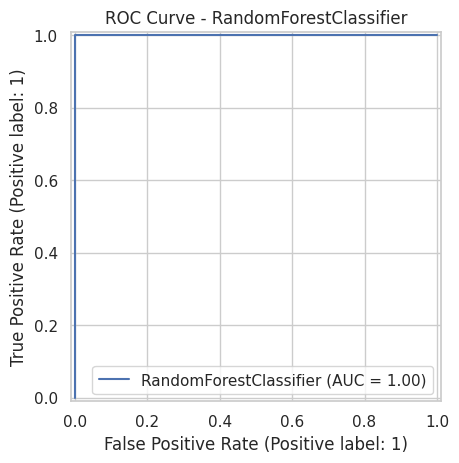

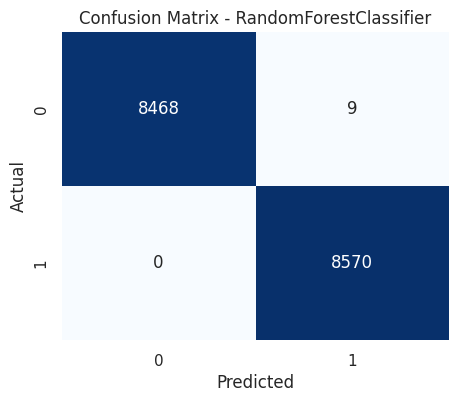

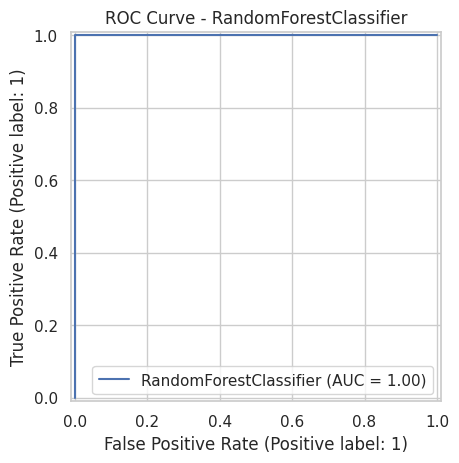

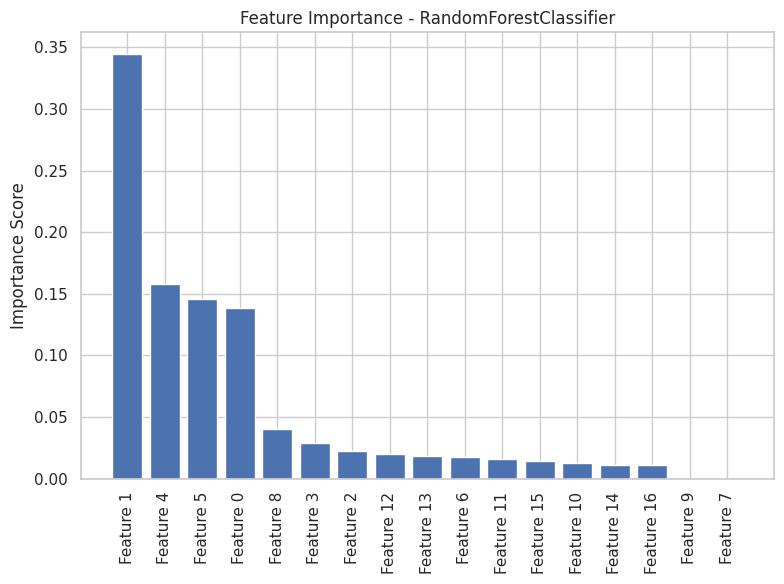

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

# 1. Initialize and Train RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)


# 2. Predictions and Evaluation
y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print("\n📊 Classification Report - RandomForestClassifier:")
print(classification_report(y_test, y_pred_rf))
print("✅ ROC-AUC Score - RandomForestClassifier:", roc_auc_score(y_test, y_pred_proba_rf))

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix - RandomForestClassifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve
RocCurveDisplay.from_estimator(rf_model, X_test_scaled, y_test)
plt.title("ROC Curve - RandomForestClassifier")
plt.show()


# Step 7: Confusion Matrix Plot
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix - RandomForestClassifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Step 8: ROC Curve Plot
RocCurveDisplay.from_estimator(rf_model, X_test_scaled, y_test)
plt.title("ROC Curve - RandomForestClassifier")
plt.show()

# Step 9: Feature Importance Plot
importances = rf_model.feature_importances_
feature_names = [f"Feature {i}" for i in range(X.shape[1])]
sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 6))
plt.bar(range(len(importances)), importances[sorted_idx], tick_label=np.array(feature_names)[sorted_idx])
plt.title("Feature Importance - RandomForestClassifier")
plt.xticks(rotation=90)
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.74      0.77      8524
           1       0.76      0.83      0.79      8523

    accuracy                           0.78     17047
   macro avg       0.79      0.78      0.78     17047
weighted avg       0.79      0.78      0.78     17047



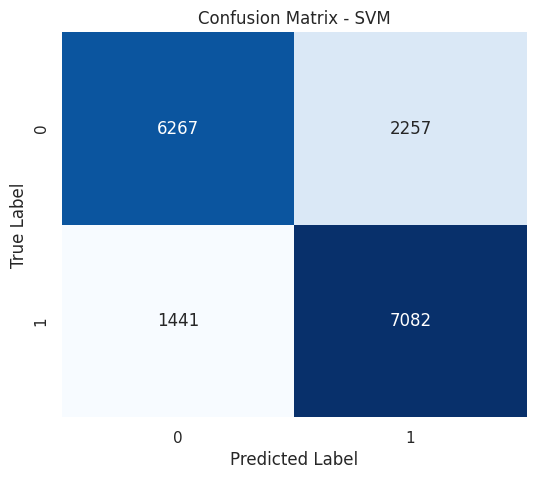

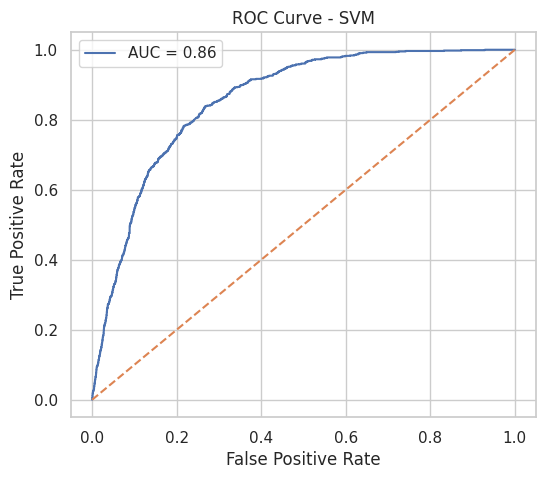

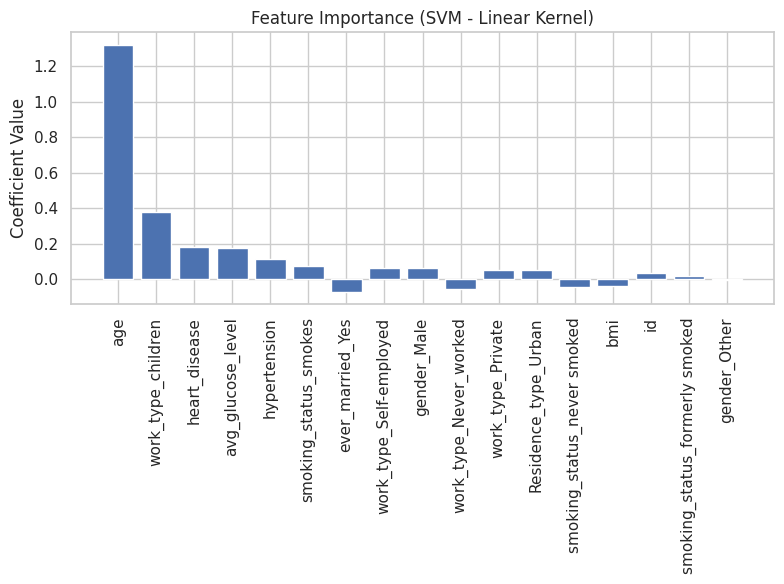

In [ ]:
# =========================================
# Import Required Libraries
# =========================================
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================
# 1️⃣ Train-Test Split
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # important for medical datasets
)

# =========================================
# 2️⃣ Feature Scaling (MANDATORY for SVM)
# =========================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================================
# 3️⃣ Train SVM Model (Linear Kernel)
# =========================================
svm_model = SVC(
    kernel='linear',
    probability=True,     # required for ROC curve
    class_weight='balanced',  # handle imbalance
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

# =========================================
# 4️⃣ Predictions & Evaluation
# =========================================
y_pred = svm_model.predict(X_test_scaled)
y_prob = svm_model.predict_proba(X_test_scaled)[:, 1]

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

# =========================================
# 5️⃣ Confusion Matrix
# =========================================
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# =========================================
# 6️⃣ ROC Curve
# =========================================
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM")
plt.legend()
plt.grid(True)
plt.show()

# =========================================
# 7️⃣ Feature Importance (Linear SVM)
# =========================================
feature_names = X.columns.tolist()
coefficients = svm_model.coef_[0]

# Sort by absolute importance
sorted_idx = np.argsort(np.abs(coefficients))[::-1]

plt.figure(figsize=(8, 6))
plt.bar(
    range(len(coefficients)),
    coefficients[sorted_idx],
    tick_label=np.array(feature_names)[sorted_idx]
)
plt.xticks(rotation=90)
plt.ylabel("Coefficient Value")
plt.title("Feature Importance (SVM - Linear Kernel)")
plt.tight_layout()
plt.show()
